In [1]:
import pandas as pd
import math
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import statistics

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cabai merah.csv", sep=";")
df

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),58495,51150
1,Apr 2017 (II),59712,50700
2,Apr 2017 (III),51705,50850
3,Apr 2017 (IV),53092,51400
4,May 2017 (V),53954,56150
...,...,...,...
302,Jan 2023 (IV),50138,45850
303,Feb 2023 (I),52962,54150
304,Feb 2023 (II),54819,58300
305,Feb 2023 (III),58716,59000


In [3]:
df_copy = df.copy()

last = len(df_copy.index)
nPred = 15

df_copy = df_copy.drop(index=df.index[last-nPred:last])

df_copy.reset_index(inplace=True, drop=True)
df_copy

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),58495,51150
1,Apr 2017 (II),59712,50700
2,Apr 2017 (III),51705,50850
3,Apr 2017 (IV),53092,51400
4,May 2017 (V),53954,56150
...,...,...,...
287,Oct 2022 (III),51969,32050
288,Oct 2022 (IV),48298,28900
289,Oct 2022 (V),45580,23550
290,Nov 2022 (I),44428,23750


In [4]:
df_copy

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),58495,51150
1,Apr 2017 (II),59712,50700
2,Apr 2017 (III),51705,50850
3,Apr 2017 (IV),53092,51400
4,May 2017 (V),53954,56150
...,...,...,...
287,Oct 2022 (III),51969,32050
288,Oct 2022 (IV),48298,28900
289,Oct 2022 (V),45580,23550
290,Nov 2022 (I),44428,23750


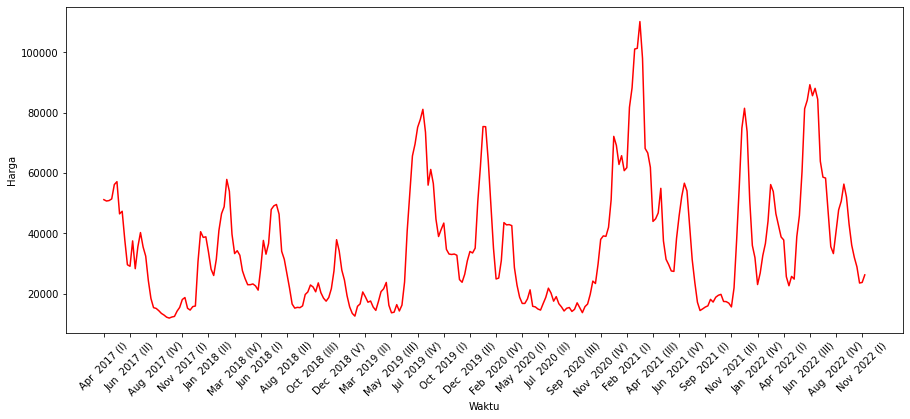

In [5]:
plt.figure(figsize=(15,6))
plt.plot(df_copy['Komoditas (Rp)'], df_copy['Jawa Timur'], color='red')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(df_copy.index)-1,10))
plt.show()

In [6]:
sd = statistics.pstdev(df_copy['Jawa Timur'].to_numpy())
meanS = statistics.mean(df_copy['Jawa Timur'].to_numpy())
print("Koefisien Variasi = ",sd/meanS*100,"%")

Koefisien Variasi =  56.843165815625284 %


In [7]:
Dt = df_copy['Jawa Timur']
Dmin = Dt.min()
Dmax = Dt.max()
N = Dt.count()
Z1 = 950
Z2 = 400

print(Dmin, Dmax, N)

11950 110100 292


In [8]:
R = Dmax+Z2 - (Dmin-Z1)
print(R)

99500


In [9]:
dif = []
df2 = df_copy

for i in range (N-1):
    dt = df['Jawa Timur'][i]
    dt2 = df['Jawa Timur'][i+1]
    ab = round(abs(dt2-dt),2)
    df2.at[i, '|Dt+1 - Dt|'] = ab

df2.at[N-1, '|Dt+1 - Dt|'] = 0

In [10]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|
0,Apr 2017 (I),58495,51150,450.0
1,Apr 2017 (II),59712,50700,150.0
2,Apr 2017 (III),51705,50850,550.0
3,Apr 2017 (IV),53092,51400,4750.0
4,May 2017 (V),53954,56150,950.0
...,...,...,...,...
287,Oct 2022 (III),51969,32050,3150.0
288,Oct 2022 (IV),48298,28900,5350.0
289,Oct 2022 (V),45580,23550,200.0
290,Nov 2022 (I),44428,23750,2500.0


In [11]:
mean = (sum(df2['|Dt+1 - Dt|']))/(N-1)
print(mean)

4861.168384879725


In [12]:
K = mean/2
if(K<1):
    K = round(K,1)
else:
    K = math.ceil(K)

print(K)

2431


In [13]:
n = math.ceil(R/K)
print(n)

41


In [14]:
himpFuzzy = pd.DataFrame()
ui = []
batasBawah = []
batasAtas = []
Ai = []
ui.append('u1')
Ai.append('A1')
batasBawah.append(Dmin-Z1)
batasAtas.append(batasBawah[0] + K)

for i in range(1, n):
    ui.append('u'+str(i+1))
    Ai.append('A'+str(i+1))
    batasBawah.append(batasAtas[i-1])
    batasAtas.append(batasBawah[i] + K)

himpFuzzy['ui'] = ui
himpFuzzy['Ai'] = Ai
himpFuzzy['batas bawah'] = batasBawah
himpFuzzy['batas atas'] = batasAtas

In [15]:
himpFuzzy['mi'] = (himpFuzzy['batas bawah'] + himpFuzzy['batas atas'])/2

In [16]:
himpFuzzy

,ui,Ai,batas bawah,batas atas,mi
0,u1,A1,11000,13431,12215.5
1,u2,A2,13431,15862,14646.5
2,u3,A3,15862,18293,17077.5
3,u4,A4,18293,20724,19508.5
4,u5,A5,20724,23155,21939.5
5,u6,A6,23155,25586,24370.5
6,u7,A7,25586,28017,26801.5
7,u8,A8,28017,30448,29232.5
8,u9,A9,30448,32879,31663.5
9,u10,A10,32879,35310,34094.5


In [17]:
# FLR dan FLRG
data = df2['Jawa Timur']

hasilFuzzy = []
for i in data:
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= i 
    cond2 = copyHimp['batas atas'] >= i 
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    hasilFuzzy.append(fuzzyfikasi)

df2['fuzzyfikasi'] = hasilFuzzy

In [18]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi
0,Apr 2017 (I),58495,51150,450.0,A17
1,Apr 2017 (II),59712,50700,150.0,A17
2,Apr 2017 (III),51705,50850,550.0,A17
3,Apr 2017 (IV),53092,51400,4750.0,A17
4,May 2017 (V),53954,56150,950.0,A19
...,...,...,...,...,...
287,Oct 2022 (III),51969,32050,3150.0,A9
288,Oct 2022 (IV),48298,28900,5350.0,A8
289,Oct 2022 (V),45580,23550,200.0,A6
290,Nov 2022 (I),44428,23750,2500.0,A6


In [19]:
nextState = []
for k in range(0, len(df2.index)-1):
    neSt = df2['fuzzyfikasi'].iloc[k+1]
    nextState.append(neSt)

df2['next state'] = pd.Series(nextState)

In [20]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state
0,Apr 2017 (I),58495,51150,450.0,A17,A17
1,Apr 2017 (II),59712,50700,150.0,A17,A17
2,Apr 2017 (III),51705,50850,550.0,A17,A17
3,Apr 2017 (IV),53092,51400,4750.0,A17,A19
4,May 2017 (V),53954,56150,950.0,A19,A19
...,...,...,...,...,...,...
287,Oct 2022 (III),51969,32050,3150.0,A9,A8
288,Oct 2022 (IV),48298,28900,5350.0,A8,A6
289,Oct 2022 (V),45580,23550,200.0,A6,A6
290,Nov 2022 (I),44428,23750,2500.0,A6,A7


In [21]:
# FLRG
dfFLRG = pd.DataFrame()
dfFLRG['Ai'] = himpFuzzy['Ai']
dfFLRG['FLRG'] = ''

# ambil df2 kecuali baris terakhir karena next statenya kosong
df3 = df2[:-1]

for f in range(len(dfFLRG.index)):
    searchAi = 'A'+str(f+1)
    
    new = df3[df3['fuzzyfikasi'].isin([searchAi])]
    group = new['next state']
    group = group.to_numpy()
    
    if len(group) > 0 :
        dfFLRG['FLRG'][f] = group

In [22]:
dfFLRG

,Ai,FLRG
0,A1,"[A1, A1, A1, A1, A2, A2]"
1,A2,"[A2, A2, A2, A1, A2, A3, A2, A2, A3, A2, A2, A..."
2,A3,"[A4, A9, A2, A4, A4, A4, A3, A2, A4, A2, A2, A..."
3,A4,"[A2, A2, A4, A5, A6, A4, A3, A5, A2, A4, A3, A..."
4,A5,"[A5, A6, A5, A8, A3, A5, A4, A7, A6, A4, A2, A..."
5,A6,"[A4, A5, A5, A4, A4, A3, A13, A6, A7, A6, A9, ..."
6,A7,"[A9, A6, A5, A12, A6, A9, A7, A12, A9, A5, A6]"
7,A8,"[A8, A11, A11, A7, A11, A5, A12, A7, A6]"
8,A9,"[A6, A13, A13, A7, A7, A6, A10, A14, A8, A6, A..."
9,A10,"[A8, A10, A9, A11, A9, A7, A10, A10, A10, A9, ..."


In [23]:
# hasil fuzzyfikasi
dfFLRG['defuzzyfikasi'] = ''

for g in range(len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[g]
    flrg = dfFLRG['FLRG'].loc[g]
    hasil = 0

    if (len(flrg) == 0):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == ai]['mi']
        hasil = fuzzyfikasi.values[0]
    
    elif (len(flrg) == 1):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == flrg[0]]['mi']
        hasil = fuzzyfikasi.values[0]
        
    else:
        lenFlrg = len(flrg)
        for h in range(len(flrg)):
            mi = himpFuzzy[himpFuzzy['Ai'] == flrg[h]]['mi']
            bobot = (1/len(flrg)) * mi.values[0]
            hasil = hasil + bobot
            

    dfFLRG['defuzzyfikasi'][g] = hasil

In [24]:
dfFLRG

,Ai,FLRG,defuzzyfikasi
0,A1,"[A1, A1, A1, A1, A2, A2]",13025.833333
1,A2,"[A2, A2, A2, A1, A2, A3, A2, A2, A3, A2, A2, A...",15434.932432
2,A3,"[A4, A9, A2, A4, A4, A4, A3, A2, A4, A2, A2, A...",18106.0
3,A4,"[A2, A2, A4, A5, A6, A4, A3, A5, A2, A4, A3, A...",19161.214286
4,A5,"[A5, A6, A5, A8, A3, A5, A4, A7, A6, A4, A2, A...",23560.166667
5,A6,"[A4, A5, A5, A4, A4, A3, A13, A6, A7, A6, A9, ...",25228.5
6,A7,"[A9, A6, A5, A12, A6, A9, A7, A12, A9, A5, A6]",28790.5
7,A8,"[A8, A11, A11, A7, A11, A5, A12, A7, A6]",30853.166667
8,A9,"[A6, A13, A13, A7, A7, A6, A10, A14, A8, A6, A...",31102.5
9,A10,"[A8, A10, A9, A11, A9, A7, A10, A10, A10, A9, ...",33932.433333


In [25]:
df2['yt'] = ''

for y in range (len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[y]
    listAi = df2[df2['fuzzyfikasi'] == ai]
    yt = dfFLRG['defuzzyfikasi'][y]
    
    if len(listAi) > 0:
        idx = listAi.index
        for z in idx:
            df2.at[z+1,'yt'] = yt

In [26]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),58495.0,51150.0,450.0,A17,A17,
1,Apr 2017 (II),59712.0,50700.0,150.0,A17,A17,53542.5
2,Apr 2017 (III),51705.0,50850.0,550.0,A17,A17,53542.5
3,Apr 2017 (IV),53092.0,51400.0,4750.0,A17,A19,53542.5
4,May 2017 (V),53954.0,56150.0,950.0,A19,A19,53542.5
...,...,...,...,...,...,...,...
288,Oct 2022 (IV),48298.0,28900.0,5350.0,A8,A6,31102.5
289,Oct 2022 (V),45580.0,23550.0,200.0,A6,A6,30853.166667
290,Nov 2022 (I),44428.0,23750.0,2500.0,A6,A7,25228.5
291,Nov 2022 (II),43777.0,26250.0,0.0,A7,NaN,25228.5


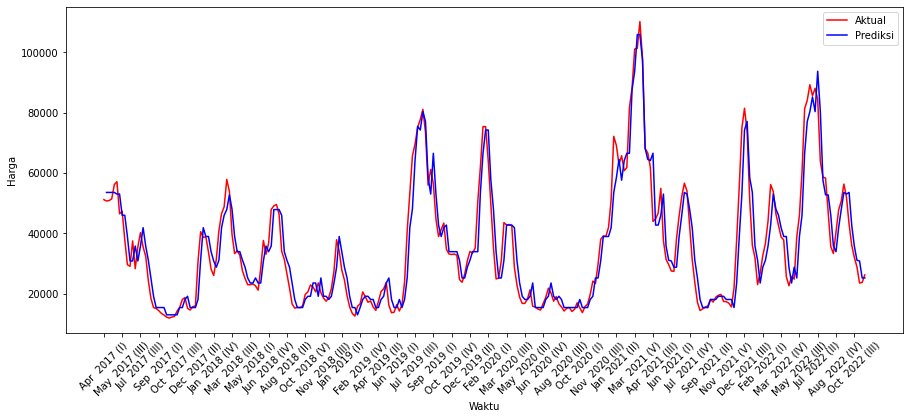

In [27]:
df2_copy = df2.copy()
df2_copy = df2_copy.drop(index=df2_copy.index[-1])
df2_copy.reset_index(inplace=True, drop=True)
df2_copy
plt.figure(figsize=(15,6))
plt.plot(df2_copy['Komoditas (Rp)'], df2_copy['Jawa Timur'], color='red', label='Aktual')
plt.plot(df2_copy['Komoditas (Rp)'][1:], df2_copy['yt'][1:], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(df2_copy.index),7))
plt.legend()
plt.show()

In [28]:
# MAPE
y_actual = df2['Jawa Timur'][1:-1].to_numpy()
y_predict = df2['yt'][1:-1].to_numpy()

# MAE
MAE = mean_absolute_error(y_actual, y_predict)
print("MAE = ",MAE)

# Root MSE squared=False
RMSE = mean_squared_error(y_actual, y_predict, squared=False)
print("RMSE = ",RMSE)

MAPE = mean_absolute_percentage_error(y_actual, y_predict)
print("MAPE = ",MAPE*100)

MAE =  4421.409597815784
RMSE =  6175.412320233839
MAPE =  13.152175224250428


In [29]:
lastIndex = len(df2.index)
dfPredictNext = df2

for n in range (nPred-1):
    # Add fuzzyfikai dr hasil predict
    nilaiYt = dfPredictNext['yt'][lastIndex-1+n]
    
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= nilaiYt
    cond2 = copyHimp['batas atas'] >= nilaiYt
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    dfPredictNext.at[lastIndex + n-1, 'fuzzyfikasi'] = fuzzyfikasi

    # add predict
    yt = dfFLRG['defuzzyfikasi'][dfFLRG['Ai'] == fuzzyfikasi]
    dfPredictNext.at[lastIndex+n, 'yt'] = yt.values[0]    

In [30]:
dfPredictNext

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),58495.0,51150.0,450.0,A17,A17,
1,Apr 2017 (II),59712.0,50700.0,150.0,A17,A17,53542.5
2,Apr 2017 (III),51705.0,50850.0,550.0,A17,A17,53542.5
3,Apr 2017 (IV),53092.0,51400.0,4750.0,A17,A19,53542.5
4,May 2017 (V),53954.0,56150.0,950.0,A19,A19,53542.5
...,...,...,...,...,...,...,...
302,NaN,NaN,NaN,NaN,A9,NaN,31102.5
303,NaN,NaN,NaN,NaN,A9,NaN,31102.5
304,NaN,NaN,NaN,NaN,A9,NaN,31102.5
305,NaN,NaN,NaN,NaN,A9,NaN,31102.5


In [31]:
dfPredictNext[len(dfPredictNext.index)-nPred:]

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
292,NaN,NaN,NaN,NaN,A8,NaN,28790.5
293,NaN,NaN,NaN,NaN,A9,NaN,30853.166667
294,NaN,NaN,NaN,NaN,A9,NaN,31102.5
295,NaN,NaN,NaN,NaN,A9,NaN,31102.5
296,NaN,NaN,NaN,NaN,A9,NaN,31102.5
297,NaN,NaN,NaN,NaN,A9,NaN,31102.5
298,NaN,NaN,NaN,NaN,A9,NaN,31102.5
299,NaN,NaN,NaN,NaN,A9,NaN,31102.5
300,NaN,NaN,NaN,NaN,A9,NaN,31102.5
301,NaN,NaN,NaN,NaN,A9,NaN,31102.5


In [32]:
df_result = df.copy()
df_result['yt'] = df2['yt']
df_result

,Komoditas (Rp),Semua Provinsi,Jawa Timur,yt
0,Apr 2017 (I),58495,51150,
1,Apr 2017 (II),59712,50700,53542.5
2,Apr 2017 (III),51705,50850,53542.5
3,Apr 2017 (IV),53092,51400,53542.5
4,May 2017 (V),53954,56150,53542.5
...,...,...,...,...
302,Jan 2023 (IV),50138,45850,31102.5
303,Feb 2023 (I),52962,54150,31102.5
304,Feb 2023 (II),54819,58300,31102.5
305,Feb 2023 (III),58716,59000,31102.5


In [33]:
df_result[len(df_result.index)-nPred:]

,Komoditas (Rp),Semua Provinsi,Jawa Timur,yt
292,Nov 2022 (III),45206,27600,28790.5
293,Nov 2022 (IV),45038,27650,30853.166667
294,Dec 2022 (I),50598,37550,31102.5
295,Dec 2022 (II),51564,31500,31102.5
296,Dec 2022 (III),51486,31300,31102.5
297,Dec 2022 (IV),56567,42850,31102.5
298,Jan 2023 (V),64748,57200,31102.5
299,Jan 2023 (I),60212,49450,31102.5
300,Jan 2023 (II),53972,41850,31102.5
301,Jan 2023 (III),52336,46000,31102.5


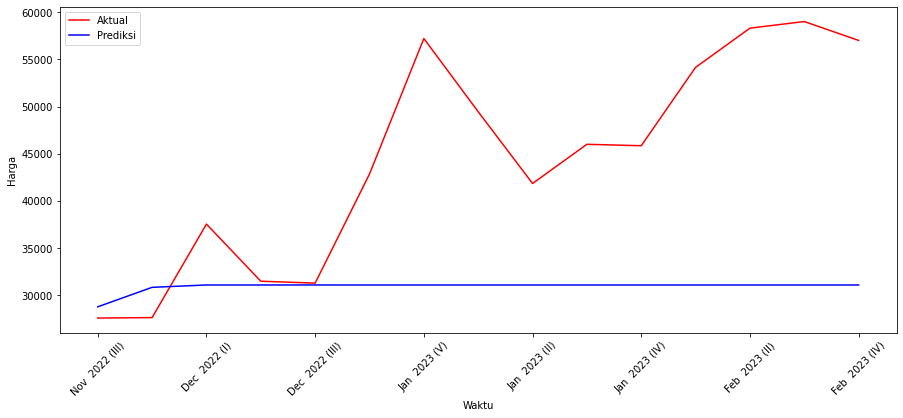

In [34]:
plt.figure(figsize=(15,6))
plt.plot(df_result['Komoditas (Rp)'][len(df_result.index)-nPred:], df_result['Jawa Timur'][len(df_result.index)-nPred:], color='red', label='Aktual')
plt.plot(df_result['Komoditas (Rp)'][len(df_result.index)-nPred:], df_result['yt'][len(df_result.index)-nPred:], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,nPred,2))
plt.legend()
plt.show()

In [35]:
# MAPE pred
y_actualpred = df_result['Jawa Timur'][last-nPred:len(df_result.index)].to_numpy()
y_predictpred = df_result['yt'][last-nPred:len(df_result.index)].to_numpy()

# MAPE
MAPE2 = mean_absolute_percentage_error(y_actualpred, y_predictpred)
# Root MSE squared=False
RMSE2 = mean_squared_error(y_actualpred, y_predictpred, squared=False)
# MAE
MAE2 = mean_absolute_error(y_actualpred, y_predictpred)

print("Hasil MAPE untuk memprediksi data",nPred,"periode kedepan")
print("MAE = ",MAE2)
print("RMSE = ",RMSE2)
print("MAPE = ",MAPE2*100)

Hasil MAPE untuk memprediksi data 15 periode kedepan
MAE =  14137.411111111109
RMSE =  17289.561683656495
MAPE =  27.817859109827246


In [36]:
# MAPE all
y_actual2 = df_result['Jawa Timur'][1:len(df_result.index)].to_numpy()
# print(y_actual2)
y_predict2 = df_result['yt'][1:len(df_result.index)].to_numpy()
# MAPE
MAPE3 = mean_absolute_percentage_error(y_actual2, y_predict2)
# Root MSE squared=False
RMSE3 = mean_squared_error(y_actual2, y_predict2, squared=False)
# MAE
MAE3 = mean_absolute_error(y_actual2, y_predict2)
print("MAE = ",MAE3)
print("RMSE = ",RMSE3)
print("MAPE = ",MAPE3*100)

MAE =  4897.684181800849
RMSE =  7135.80401819414
MAPE =  13.871081297072822
